## Preprocessing of the Data

Most of this part has been given to us by our supervisor Oana Geman. The selection of the ERP components has been done by us.

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal as signal
import pywt
import os
from tqdm import tqdm
from sklearn.decomposition import FastICA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Data paths
data_folders = {
    "Normal": "C:\\Users\\naili\\Autism-Project-Course\\Normal\\",
    "Autism": "C:\\Users\\naili\\Autism-Project-Course\\Autism\\"
}
# Signal settings
time_window = (0.2, 1.2)  # Time range before and after marker
sample_rate = 256  # Hz
pre_marker_samples = int(time_window[0] * sample_rate)
post_marker_samples = int(time_window[1] * sample_rate)

# Bandpass filter
def bandpass_filter(data, lowcut=0.1, highcut=60.0, fs=256, order=4):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data, axis=0)

# Noise removal using ICA
def apply_ica(data):
    if data.shape[1] > 1:
        try:
            ica = FastICA(n_components=data.shape[1], random_state=42)
            return ica.fit_transform(data)
        except Exception as e:
            print(f" Error in ICA: {e}")
    return data

# Noise removal using discrete wavelet transform (only for feature extraction)
def denoise_eeg_dwt(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[1])) / 0.6745
    coeffs[1:] = [pywt.threshold(c, sigma, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

# Extracting PSD and ERP features
def extract_psd_features(segment, fs=256):
    segment = denoise_eeg_dwt(segment)
    freqs, psd = signal.welch(segment, fs, nperseg=fs)
    return psd.flatten()

import numpy as np

def extract_erp_features(segment, sample_rate):
    segment = denoise_eeg_dwt(segment) 
    time_windows = {
    "BAEP": (0.001, 0.01),   # Brainstem Auditory Evoked Potential
    "P1": (0.05, 0.08),      # Early visual attention
    "N1": (0.08, 0.15),      # Early sensory discrimination
    "P100": (0.08, 0.12),    # Visual processing
    "MMN": (0.10, 0.25),     # Auditory change detection
    # "RewP": (0.20, 0.35),    # Reward positivity
    # "N170": (0.14, 0.20),    # Face processing
    "N2c": (0.18, 0.22),     # Cognitive control/conflict
    "P300": (0.25, 0.50),    # Attention, stimulus evaluation
    # "N400": (0.35, 0.45),    # Semantic/meaning processing
    # "P400": (0.30, 0.50),    # Face/object recognition (infants)
    # "P600": (0.50, 0.80),    # Syntax, reanalysis
    # "LPC": (0.50, 0.80),     # Late Positive Complex
    # "ERN": (0.05, 0.10),     # Error monitoring (post-response)
    # "Pe": (0.20, 0.40)       # Error awareness
    }
    
    features = []
    feature_names = []  
    
    for label, (start, end) in time_windows.items():
        start_idx, end_idx = int(start * sample_rate), int(end * sample_rate)
        segment_window = segment[start_idx:end_idx]
        
        if segment_window.size == 0:
            continue  
        
        if 'P' in label:
            peak_value = np.max(segment_window)  
            peak_latency = start + (np.argmax(segment_window) / sample_rate)  
        else:
            peak_value = np.min(segment_window)  
            peak_latency = start + (np.argmin(segment_window) / sample_rate) 
        
        mean_amplitude = np.mean(segment_window)
        
        
        features.extend([peak_value, peak_latency])
        
   
        feature_names.extend([f"{label}_Peak", f"{label}_Latency"])
    
    return features


# Data processing function
def process_data():
    all_eeg, all_psd, all_erp, labels, groups = [], [], [], [], []
    for category, folder in data_folders.items():
        for file in tqdm(sorted(os.listdir(folder)), desc=f"Processing {category}"):
            subject_id = os.path.splitext(file)[0]  # e.g., "subject01"
            
            df = pd.read_csv(os.path.join(folder, file), delimiter=", ", comment="%", engine='python')
            if "Marker Channel" not in df.columns:
                continue
            
            eeg_channels = [col for col in df.columns if "EXG Channel" in col]
            df[eeg_channels] = bandpass_filter(df[eeg_channels].values)
            df[eeg_channels] = apply_ica(df[eeg_channels].values)

            for marker in df[df["Marker Channel"] != 0].index[:98]:
                start, end = max(marker - pre_marker_samples, 0), min(marker + post_marker_samples, len(df))
                segment = df.loc[start:end, eeg_channels].copy()
                if segment.empty:
                    continue

                baseline = df.loc[max(0, start - pre_marker_samples):start, eeg_channels].mean()
                segment -= baseline

                all_eeg.append(segment.values)
                all_psd.append(extract_psd_features(segment.values.flatten(), sample_rate))
                all_erp.append(extract_erp_features(segment.values.flatten(), sample_rate))
                labels.append(0 if category == "Normal" else 1)
                groups.append(subject_id)  # add subject group

    return np.array(all_eeg), np.array(all_psd), np.array(all_erp), np.array(labels), np.array(groups)

# Process 
eeg_data, psd_data, erp_data, labels, groups = process_data()
feature_data = np.concatenate([erp_data, psd_data], axis=1)


Processing Autism: 100%|██████████| 26/26 [02:44<00:00,  6.32s/it]


In [ ]:
#=======================================
#=========Dimensions Check==============

print("ERP data shape:", feature_data.shape)
print("Labels shape:", labels.shape)
print("Groups shape:", groups.shape)

ERP data shape: (2548, 143)
Labels shape: (2548,)
Groups shape: (2548,)


In [ ]:
#========================================
#======Class Distribution================
unique, counts = np.unique(labels, return_counts=True)
print("Class distribution in dataset:")
for u, c in zip(unique, counts):
    print(f"  Class {u} ({'Normal' if u == 0 else 'Autism'}): {c}")

Class distribution in dataset:
  Class 0 (Normal): 1274
  Class 1 (Autism): 1274


### Data visualizations

In [6]:
def plot_erp_example(df, eeg_channels):
    markers = df[df["Marker Channel"] != 0].index
    erp_segments = []

    for marker in markers[:20]:
        start = max(marker - pre_marker_samples, 0)
        end = min(marker + post_marker_samples, len(df))
        segment = df.loc[start:end, eeg_channels[0]].values  # first channel
        erp_segments.append(segment[:(pre_marker_samples + post_marker_samples)])

    erp_avg = np.mean(erp_segments, axis=0)
    time_axis = np.linspace(-time_window[0], time_window[1], len(erp_avg))

    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, erp_avg)
    plt.title("Average ERP (EXG Channel 1)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.grid(True)
    plt.show()



In [7]:
sample_file = os.path.join(data_folders["Normal"], os.listdir(data_folders["Normal"])[0])
df = pd.read_csv(sample_file, delimiter=", ", comment="%", engine='python')

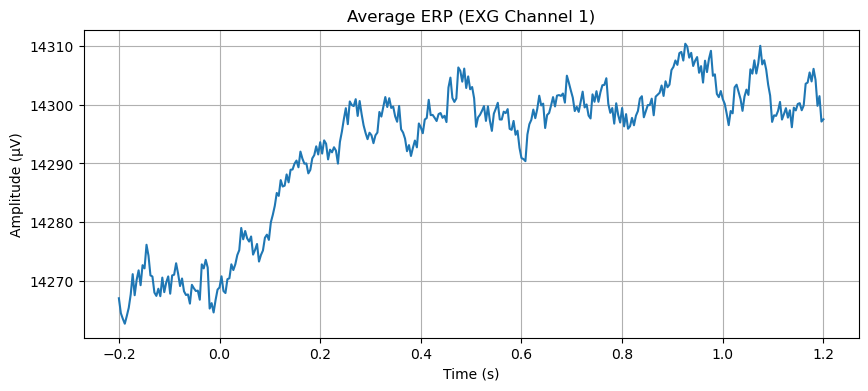

In [9]:
eeg_channels = [col for col in df.columns if "EXG Channel" in col]
plot_erp_example(df, eeg_channels)


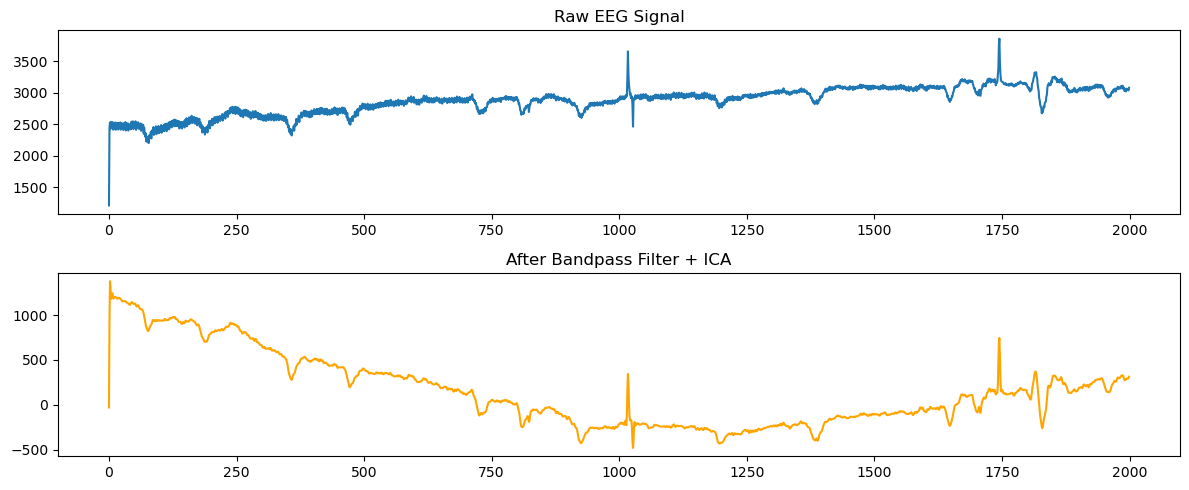

In [12]:
def plot_raw_vs_filtered(df, eeg_channels):
    raw = df[eeg_channels[0]].values[:2000]
    filtered = bandpass_filter(df[eeg_channels].values)[:2000, 0]

    plt.figure(figsize=(12, 5))
    plt.subplot(2,1,1)
    plt.plot(raw)
    plt.title("Raw EEG Signal")

    plt.subplot(2,1,2)
    plt.plot(filtered, color='orange')
    plt.title("After Bandpass Filter + ICA")
    plt.tight_layout()
    plt.show()

plot_raw_vs_filtered(df, eeg_channels)

## ERP LSTM+Transformer model

In [ ]:
# =====================================================
# MODEL DEFINITION
# =====================================================
class ERPTransformerModel(nn.Module):
    '''Here we define the model that we are using. It consists of a LSTM layer, a Transformer Encoder and
    a simple Neural Network of input and out layers.'''
    def __init__(self, erp_input_dim=2, lstm_hidden=64, transformer_dim=96,
                 n_heads=4, ff_dim=192, num_layers=2, dropout=0.3, num_classes=2):
        ''' Parameters:
            - erp_input_dim: int optional (default =2 ). The number of ERP features per ERP
            
            -lstm_hidden: int, optional. he number of hidden units in the LSTM layer, which controls the model's capacity to learn temporal dependencies.

            -transformer_dim: int, optional. The dimensionality of the Transformer encoder's input and output representations.

            -n_head: int, optional. The number of heads for the attention Transformer layer. Has to divide cleanly with trainsformer_dim

            -ff_dim: int, optional. The dimension of the feed-forward layer inside each Transformer encoder block. 

            -num_layers:int, optional.  The number of Encoder layers we stack. Preferably small considering the amount of data we have.

            -dropout: float <= 0.3. Regularization method to improve generalazation and reduce overfitting.

            -num_classes:int, optional. The number of classes we output. 2 since we have Control-Autism.

            '''
        super().__init__()

        # --- LSTM encoder ---
        self.lstm = nn.LSTM(
            input_size=erp_input_dim,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=True
        )

        # --- Transformer encoder ---
        self.proj = nn.Linear(lstm_hidden * 2, transformer_dim) #Linear projection. Converting the output of LSTM to a dimension the Transformer Encoder can fit.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="relu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # --- Attention pooling ---
        self.attn_pool = nn.Sequential(
            nn.Linear(transformer_dim, transformer_dim),
            nn.Tanh(),
            nn.Linear(transformer_dim, 1)
        )

        # --- Final classifier ---
        self.classifier = nn.Sequential(
            nn.LayerNorm(transformer_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(transformer_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x_erp, return_attention=False):
        lstm_out, _ = self.lstm(x_erp)
        x = self.proj(lstm_out)
        x = self.encoder(x)
        attn_weights = torch.softmax(self.attn_pool(x), dim=1)
        x = torch.sum(attn_weights * x, dim=1)
        logits = self.classifier(x)

        if return_attention:
            return logits, attn_weights.squeeze(-1)  # shape [B, T]
        return logits


# =====================================================
# TRAINING CONFIG
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_splits   = 5
num_epochs = 80
batch_size = 32
learning_rate = 5e-4
patience   = 8
min_delta  = 1e-4

fold_metrics = []

# =====================================================
# CROSS-VALIDATION
# =====================================================
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
splitter = sgkf.split(erp_data, labels, groups)

for fold, (train_idx, test_idx) in enumerate(splitter):
    print(f"\n===== Fold {fold+1} / {n_splits} (StratifiedGroupKFold) =====")

    # --- Split ERP data ---
    X_train, X_test = erp_data[train_idx], erp_data[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    # --- Scale training only (avoid leakage) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # --- Reshape ERP into sequence form (e.g. [P1, N1, P300,...]) ---
    feature_dim = 2  # [peak, latency] per ERP component
    seq_len = X_train_scaled.shape[1] // feature_dim
    X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], seq_len, feature_dim)
    X_test_seq  = X_test_scaled.reshape(X_test_scaled.shape[0], seq_len, feature_dim)

    # --- Convert to tensors ---
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_seq,  dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    # --- Balanced sampler ---
    class_counts = np.bincount(y_train)
    inv_freq = 1.0 / class_counts
    sample_weights = inv_freq[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, sampler=sampler
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size, shuffle=False
    )

    # =====================================================
    # MODEL SETUP
    # =====================================================
    model = ERPTransformerModel(
        erp_input_dim=feature_dim,
        lstm_hidden=64,
        transformer_dim=96,
        n_heads=4,
        ff_dim=192,
        num_layers=1,
        dropout=0.3,
        num_classes=2
    ).to(device)

    class_weights = torch.tensor(class_counts.max() / class_counts, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # =====================================================
    # TRAINING LOOP
    # =====================================================
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        all_probs, all_targets = [], []

        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                loss = criterion(outputs, y_b)
                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == y_b).sum().item()
                total += y_b.size(0)
                all_probs.extend(probs.cpu().numpy())
                all_targets.extend(y_b.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total
        try:
            val_auc = roc_auc_score(all_targets, all_probs)
        except ValueError:
            val_auc = float("nan")

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")

        scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) >= 5 and epochs_no_improve >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

    # =====================================================
    # EVALUATION
    # =====================================================
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    all_attn = []
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b = X_b.to(device)
            outputs, attn = model(X_b, return_attention=True)
            all_attn.append(attn.cpu().numpy())
            outputs = model(X_b)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y_b.numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    auc = roc_auc_score(all_targets, all_probs)
    cm = confusion_matrix(all_targets, all_preds)

    print("\nConfusion Matrix:\n", cm)
    print(classification_report(all_targets, all_preds, target_names=["Normal", "Autism"], zero_division=0))

    fold_metrics.append({
        "Fold": fold + 1,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

# =====================================================
# SUMMARY
# =====================================================
print("\n========== Cross-validation Summary ==========")
for m in fold_metrics:
    print(f"Fold {m['Fold']}: "
          f"Acc={m['Accuracy']:.4f} | Prec={m['Precision']:.4f} | "
          f"Rec={m['Recall']:.4f} | F1={m['F1']:.4f} | AUC={m['AUC']:.4f}")

print("\nAverage Performance Across Folds:")
print(f"Accuracy:  {np.mean([m['Accuracy'] for m in fold_metrics]):.4f}")
print(f"Precision: {np.mean([m['Precision'] for m in fold_metrics]):.4f}")
print(f"Recall:    {np.mean([m['Recall'] for m in fold_metrics]):.4f}")
print(f"F1-score:  {np.mean([m['F1'] for m in fold_metrics]):.4f}")
print(f"AUC:       {np.mean([m['AUC'] for m in fold_metrics]):.4f}")


Using device: cuda

===== Fold 1 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6866 | Val Loss: 0.6580 | Val Acc: 0.6582 | AUC: 0.4314
Epoch 2/80 | Train Loss: 0.6535 | Val Loss: 0.9102 | Val Acc: 0.3673 | AUC: 0.3662
Epoch 3/80 | Train Loss: 0.6103 | Val Loss: 0.8912 | Val Acc: 0.3639 | AUC: 0.3605
Epoch 4/80 | Train Loss: 0.5985 | Val Loss: 0.9895 | Val Acc: 0.3486 | AUC: 0.3589
Epoch 5/80 | Train Loss: 0.5999 | Val Loss: 0.9927 | Val Acc: 0.3146 | AUC: 0.3632
Epoch 6/80 | Train Loss: 0.5831 | Val Loss: 0.9544 | Val Acc: 0.3435 | AUC: 0.3778
Epoch 7/80 | Train Loss: 0.5885 | Val Loss: 1.0019 | Val Acc: 0.3350 | AUC: 0.3676
Epoch 8/80 | Train Loss: 0.5890 | Val Loss: 0.9591 | Val Acc: 0.3724 | AUC: 0.3580
Epoch 9/80 | Train Loss: 0.5847 | Val Loss: 0.9754 | Val Acc: 0.3231 | AUC: 0.3519
🛑 Early stopping at epoch 9

Confusion Matrix:
 [[  7 189]
 [ 12 380]]
              precision    recall  f1-score   support

      Normal       0.37      0.04      0.07       196
      A

Visualize the attention.

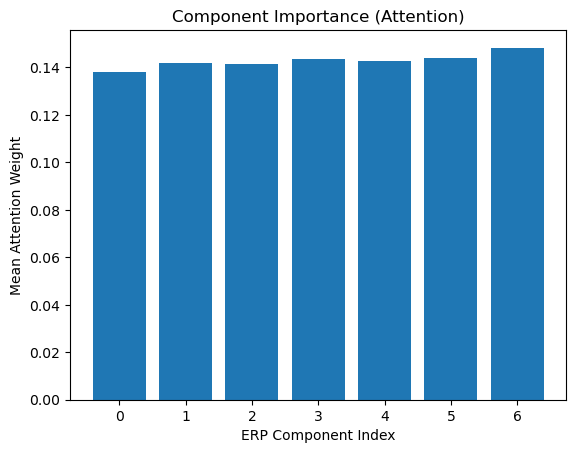

In [44]:
mean_attention = np.mean(np.vstack(all_attn), axis=0)
plt.bar(range(seq_len), mean_attention)
plt.xlabel("ERP Component Index")
plt.ylabel("Mean Attention Weight")
plt.title("Component Importance (Attention)")
plt.show()

We can see that none of the Components heavily effect the decision of the model. This can be due to the lack of data.


### Same training loop but with some kind of Data Augmentation Gaussian Noise. This version is the one we used in our report.

Using device: cuda

===== Fold 1 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6994 | Val Loss: 0.6692 | Val Acc: 0.6378 | AUC: 0.5046
Epoch 2/80 | Train Loss: 0.6738 | Val Loss: 0.8387 | Val Acc: 0.3810 | AUC: 0.3863
Epoch 3/80 | Train Loss: 0.6331 | Val Loss: 0.8731 | Val Acc: 0.4286 | AUC: 0.3742
Epoch 4/80 | Train Loss: 0.6196 | Val Loss: 0.9940 | Val Acc: 0.3435 | AUC: 0.3648
Epoch 5/80 | Train Loss: 0.6007 | Val Loss: 0.9097 | Val Acc: 0.4167 | AUC: 0.3707
Epoch 6/80 | Train Loss: 0.5932 | Val Loss: 1.0143 | Val Acc: 0.3384 | AUC: 0.3638
Epoch 7/80 | Train Loss: 0.5850 | Val Loss: 0.9630 | Val Acc: 0.3793 | AUC: 0.3644
Epoch 8/80 | Train Loss: 0.5745 | Val Loss: 0.9978 | Val Acc: 0.3622 | AUC: 0.3644
Epoch 9/80 | Train Loss: 0.5803 | Val Loss: 1.0088 | Val Acc: 0.3452 | AUC: 0.3734
🛑 Early stopping at epoch 9


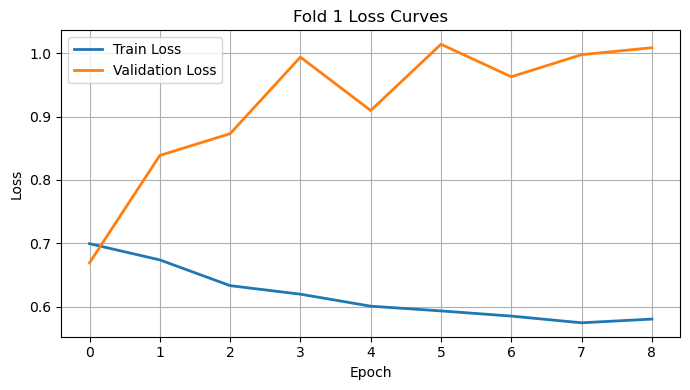


Confusion Matrix:
 [[  7 189]
 [ 24 368]]
              precision    recall  f1-score   support

      Normal       0.23      0.04      0.06       196
      Autism       0.66      0.94      0.78       392

    accuracy                           0.64       588
   macro avg       0.44      0.49      0.42       588
weighted avg       0.52      0.64      0.54       588


===== Fold 2 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6945 | Val Loss: 0.6984 | Val Acc: 0.4490 | AUC: 0.5315
Epoch 2/80 | Train Loss: 0.6941 | Val Loss: 0.6878 | Val Acc: 0.5286 | AUC: 0.5404
Epoch 3/80 | Train Loss: 0.6933 | Val Loss: 0.6830 | Val Acc: 0.5367 | AUC: 0.5303
Epoch 4/80 | Train Loss: 0.6905 | Val Loss: 0.6514 | Val Acc: 0.6000 | AUC: 0.7875
Epoch 5/80 | Train Loss: 0.6897 | Val Loss: 0.6612 | Val Acc: 0.6469 | AUC: 0.7486
Epoch 6/80 | Train Loss: 0.6879 | Val Loss: 0.6365 | Val Acc: 0.7837 | AUC: 0.8341
Epoch 7/80 | Train Loss: 0.6850 | Val Loss: 0.6514 | Val Acc: 0.5735 | AUC: 0.7853
Ep

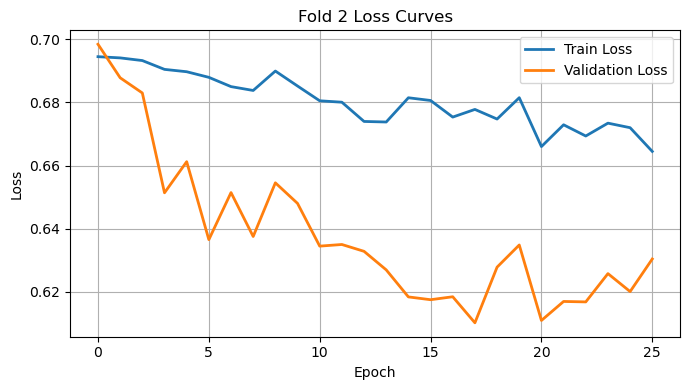


Confusion Matrix:
 [[227  67]
 [ 49 147]]
              precision    recall  f1-score   support

      Normal       0.82      0.77      0.80       294
      Autism       0.69      0.75      0.72       196

    accuracy                           0.76       490
   macro avg       0.75      0.76      0.76       490
weighted avg       0.77      0.76      0.76       490


===== Fold 3 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6936 | Val Loss: 0.6827 | Val Acc: 0.6000 | AUC: 0.5712
Epoch 2/80 | Train Loss: 0.6974 | Val Loss: 0.6846 | Val Acc: 0.6000 | AUC: 0.5407
Epoch 3/80 | Train Loss: 0.6945 | Val Loss: 0.6833 | Val Acc: 0.6000 | AUC: 0.5652
Epoch 4/80 | Train Loss: 0.6933 | Val Loss: 0.6826 | Val Acc: 0.6000 | AUC: 0.5853
Epoch 5/80 | Train Loss: 0.6899 | Val Loss: 0.6863 | Val Acc: 0.6000 | AUC: 0.5745
Epoch 6/80 | Train Loss: 0.6949 | Val Loss: 0.6878 | Val Acc: 0.6000 | AUC: 0.6016
Epoch 7/80 | Train Loss: 0.6915 | Val Loss: 0.6882 | Val Acc: 0.6041 | AUC: 0.5721
Ep

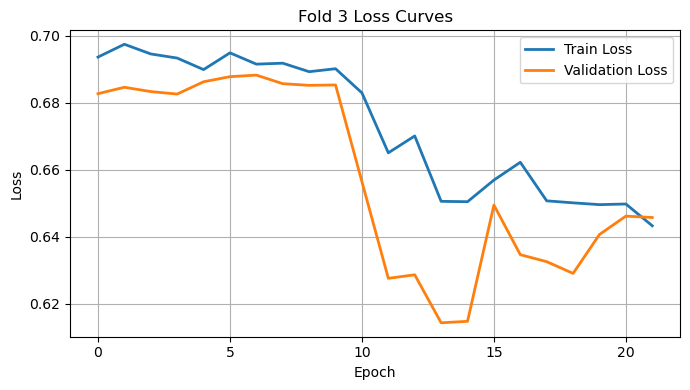


Confusion Matrix:
 [[202  92]
 [ 48 148]]
              precision    recall  f1-score   support

      Normal       0.81      0.69      0.74       294
      Autism       0.62      0.76      0.68       196

    accuracy                           0.71       490
   macro avg       0.71      0.72      0.71       490
weighted avg       0.73      0.71      0.72       490


===== Fold 4 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6954 | Val Loss: 0.6853 | Val Acc: 0.6061 | AUC: 0.5544
Epoch 2/80 | Train Loss: 0.6898 | Val Loss: 0.6687 | Val Acc: 0.6020 | AUC: 0.5539
Epoch 3/80 | Train Loss: 0.6962 | Val Loss: 0.6906 | Val Acc: 0.5918 | AUC: 0.5394
Epoch 4/80 | Train Loss: 0.6930 | Val Loss: 0.6734 | Val Acc: 0.6082 | AUC: 0.5556
Epoch 5/80 | Train Loss: 0.6915 | Val Loss: 0.6793 | Val Acc: 0.6531 | AUC: 0.5638
Epoch 6/80 | Train Loss: 0.6897 | Val Loss: 0.6719 | Val Acc: 0.6020 | AUC: 0.4822
Epoch 7/80 | Train Loss: 0.6907 | Val Loss: 0.6844 | Val Acc: 0.6020 | AUC: 0.4737
Ep

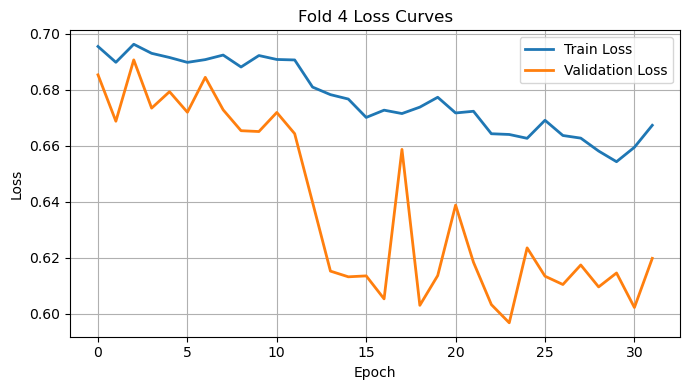


Confusion Matrix:
 [[138  58]
 [ 84 210]]
              precision    recall  f1-score   support

      Normal       0.62      0.70      0.66       196
      Autism       0.78      0.71      0.75       294

    accuracy                           0.71       490
   macro avg       0.70      0.71      0.70       490
weighted avg       0.72      0.71      0.71       490


===== Fold 5 / 5 (StratifiedGroupKFold) =====
Epoch 1/80 | Train Loss: 0.6926 | Val Loss: 0.6932 | Val Acc: 0.5571 | AUC: 0.4546
Epoch 2/80 | Train Loss: 0.6907 | Val Loss: 0.6928 | Val Acc: 0.6000 | AUC: 0.4476
Epoch 3/80 | Train Loss: 0.6779 | Val Loss: 0.7115 | Val Acc: 0.4776 | AUC: 0.4711
Epoch 4/80 | Train Loss: 0.6727 | Val Loss: 0.7048 | Val Acc: 0.4816 | AUC: 0.5397
Epoch 5/80 | Train Loss: 0.6591 | Val Loss: 0.7221 | Val Acc: 0.4898 | AUC: 0.5441
Epoch 6/80 | Train Loss: 0.6649 | Val Loss: 0.6733 | Val Acc: 0.5816 | AUC: 0.5720
Epoch 7/80 | Train Loss: 0.6512 | Val Loss: 0.6921 | Val Acc: 0.5347 | AUC: 0.5801
Ep

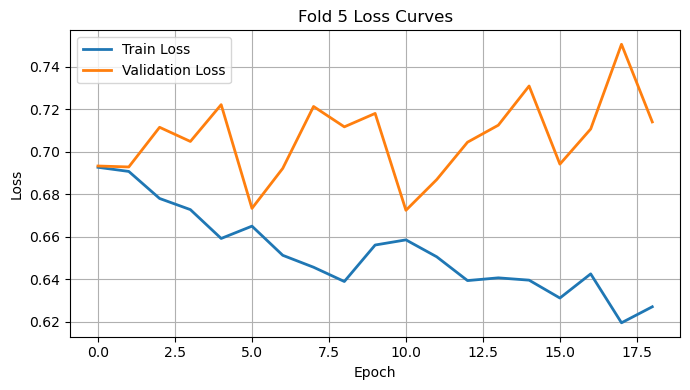


Confusion Matrix:
 [[182 112]
 [ 95 101]]
              precision    recall  f1-score   support

      Normal       0.66      0.62      0.64       294
      Autism       0.47      0.52      0.49       196

    accuracy                           0.58       490
   macro avg       0.57      0.57      0.57       490
weighted avg       0.58      0.58      0.58       490


========== Cross-validation Summary ==========
Fold 1: Acc=0.6378 | Prec=0.6607 | Rec=0.9388 | F1=0.7756 | AUC=0.5046
Fold 2: Acc=0.7633 | Prec=0.6869 | Rec=0.7500 | F1=0.7171 | AUC=0.8108
Fold 3: Acc=0.7143 | Prec=0.6167 | Rec=0.7551 | F1=0.6789 | AUC=0.7548
Fold 4: Acc=0.7102 | Prec=0.7836 | Rec=0.7143 | F1=0.7473 | AUC=0.7421
Fold 5: Acc=0.5776 | Prec=0.4742 | Rec=0.5153 | F1=0.4939 | AUC=0.5639

Average Performance Across Folds:
Accuracy:  0.6806
Precision: 0.6444
Recall:    0.7347
F1-score:  0.6825
AUC:       0.6752


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_splits   = 5
num_epochs = 80
batch_size = 32
learning_rate = 5e-4
patience   = 8
min_delta  = 1e-4
noise_std  = 0.01  # Gaussian noise 

fold_metrics = []

# =====================================================
# CROSS-VALIDATION
# =====================================================
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
splitter = sgkf.split(erp_data, labels, groups)

for fold, (train_idx, test_idx) in enumerate(splitter):
    print(f"\n===== Fold {fold+1} / {n_splits} (StratifiedGroupKFold) =====")

    # --- Split ERP data ---
    X_train, X_test = erp_data[train_idx], erp_data[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    # --- Scale training only (avoid leakage) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # --- Reshape ERP into sequence form ---
    feature_dim = 2  # [peak, latency] per ERP component
    seq_len = X_train_scaled.shape[1] // feature_dim
    X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], seq_len, feature_dim)
    X_test_seq  = X_test_scaled.reshape(X_test_scaled.shape[0], seq_len, feature_dim)

    # --- Convert to tensors ---
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_seq,  dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    # --- Balanced sampler ---
    class_counts = np.bincount(y_train)
    inv_freq = 1.0 / class_counts
    sample_weights = inv_freq[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, sampler=sampler
    )
    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size, shuffle=False
    )

    # =====================================================
    # MODEL SETUP
    # =====================================================
    model = ERPTransformerModel(
        erp_input_dim=feature_dim,
        lstm_hidden=64,
        transformer_dim=96,
        n_heads=4,
        ff_dim=192,
        num_layers=1,
        dropout=0.3,
        num_classes=2
    ).to(device)

    class_weights = torch.tensor(class_counts.max() / class_counts, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # For plotting
    train_losses, val_losses = [], []

    # =====================================================
    # TRAINING LOOP
    # =====================================================
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            # Add Gaussian noise (training only)
            if noise_std > 0:
                X_b = X_b + torch.randn_like(X_b) * noise_std

            optimizer.zero_grad()
            outputs = model(X_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        all_probs, all_targets = [], []

        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                outputs = model(X_b)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                loss = criterion(outputs, y_b)
                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == y_b).sum().item()
                total += y_b.size(0)
                all_probs.extend(probs.cpu().numpy())
                all_targets.extend(y_b.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct / total
        try:
            val_auc = roc_auc_score(all_targets, all_probs)
        except ValueError:
            val_auc = float("nan")

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")

        scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) >= 5 and epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # =====================================================
    # PLOT TRAINING AND VALIDATION LOSSES
    # =====================================================
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Train Loss", linewidth=2)
    plt.plot(val_losses, label="Validation Loss", linewidth=2)
    plt.title(f"Fold {fold+1} Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # EVALUATION
    # =====================================================
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()

    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b = X_b.to(device)
            outputs = model(X_b)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y_b.numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    auc = roc_auc_score(all_targets, all_probs)
    cm = confusion_matrix(all_targets, all_preds)

    print("\nConfusion Matrix:\n", cm)
    print(classification_report(all_targets, all_preds, target_names=["Normal", "Autism"], zero_division=0))

    fold_metrics.append({
        "Fold": fold + 1,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

# =====================================================
# SUMMARY
# =====================================================
print("\n========== Cross-validation Summary ==========")
for m in fold_metrics:
    print(f"Fold {m['Fold']}: "
          f"Acc={m['Accuracy']:.4f} | Prec={m['Precision']:.4f} | "
          f"Rec={m['Recall']:.4f} | F1={m['F1']:.4f} | AUC={m['AUC']:.4f}")

print("\nAverage Performance Across Folds:")
print(f"Accuracy:  {np.mean([m['Accuracy'] for m in fold_metrics]):.4f}")
print(f"Precision: {np.mean([m['Precision'] for m in fold_metrics]):.4f}")
print(f"Recall:    {np.mean([m['Recall'] for m in fold_metrics]):.4f}")
print(f"F1-score:  {np.mean([m['F1'] for m in fold_metrics]):.4f}")
print(f"AUC:       {np.mean([m['AUC'] for m in fold_metrics]):.4f}")

In [35]:
torch.save(model.state_dict, 'ERP-LSTM-TRANSFORMER.pth')

### TRADITIONAL Machine Learning Models using KFold


========== Traditional ML Cross-Validation ==========

----- SVM -----
Fold 1: Acc=0.5020, Prec=0.5926, Rec=0.5442, F1=0.5674
Confusion Matrix:
 [[ 86 110]
 [134 160]] 



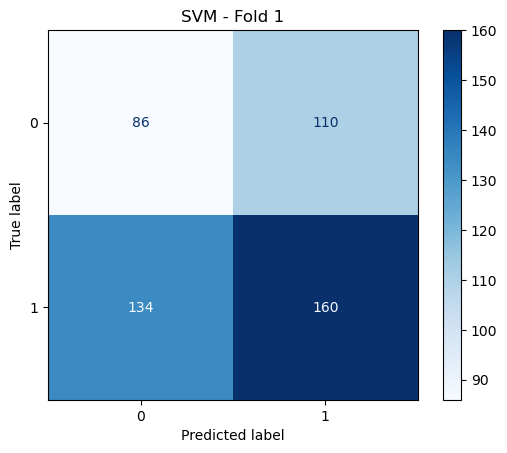

Fold 2: Acc=0.5986, Prec=0.5993, Rec=0.5952, F1=0.5973
Confusion Matrix:
 [[177 117]
 [119 175]] 



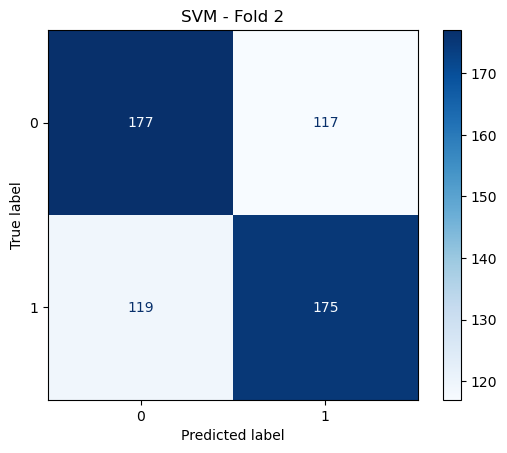

Fold 3: Acc=0.5857, Prec=0.4863, Rec=0.6327, F1=0.5499
Confusion Matrix:
 [[163 131]
 [ 72 124]] 



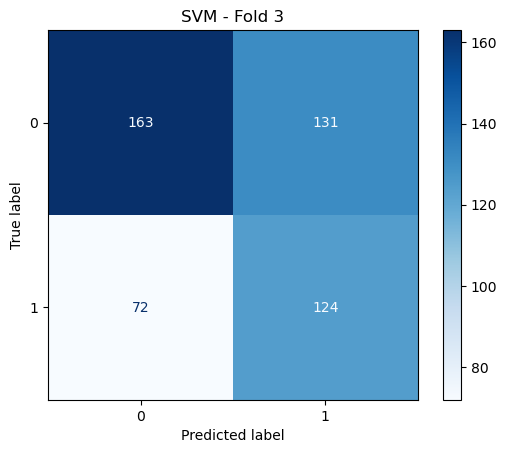

Fold 4: Acc=0.6000, Prec=0.5000, Rec=0.7806, F1=0.6096
Confusion Matrix:
 [[141 153]
 [ 43 153]] 



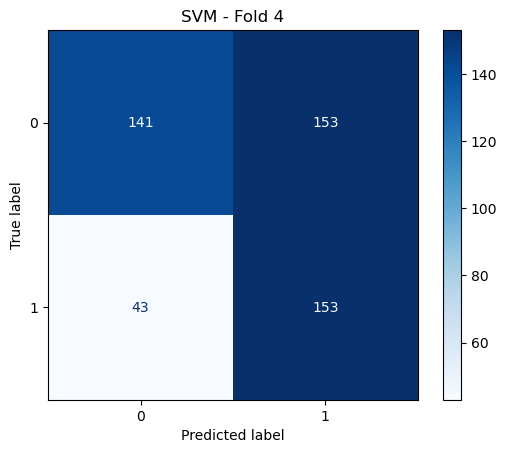

Fold 5: Acc=0.5224, Prec=0.5904, Rec=0.6667, F1=0.6262
Confusion Matrix:
 [[ 60 136]
 [ 98 196]] 



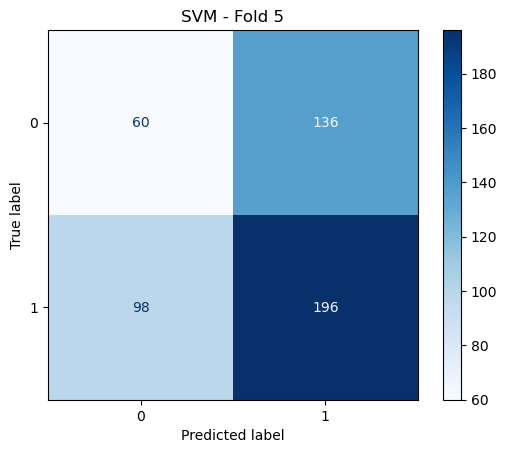


Average SVM: Acc=0.5618 | Prec=0.5537 | Rec=0.6439 | F1=0.5901


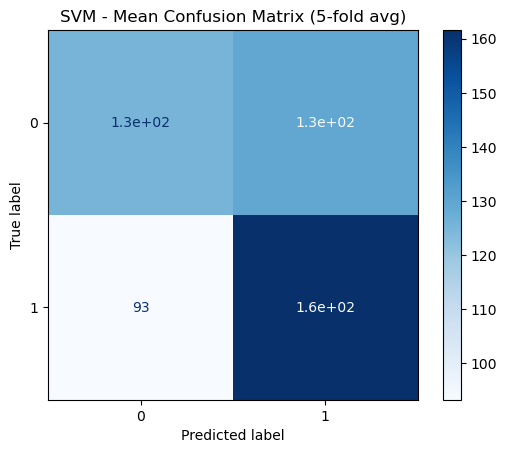


----- RandomForest -----
Fold 1: Acc=0.4265, Prec=0.5323, Rec=0.3639, F1=0.4323
Confusion Matrix:
 [[102  94]
 [187 107]] 



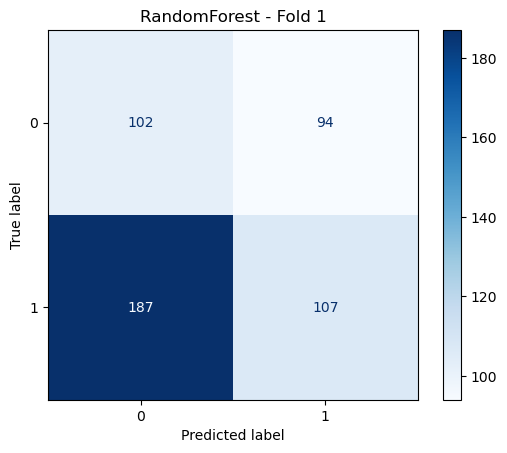

Fold 2: Acc=0.6599, Prec=0.6975, Rec=0.5646, F1=0.6241
Confusion Matrix:
 [[222  72]
 [128 166]] 



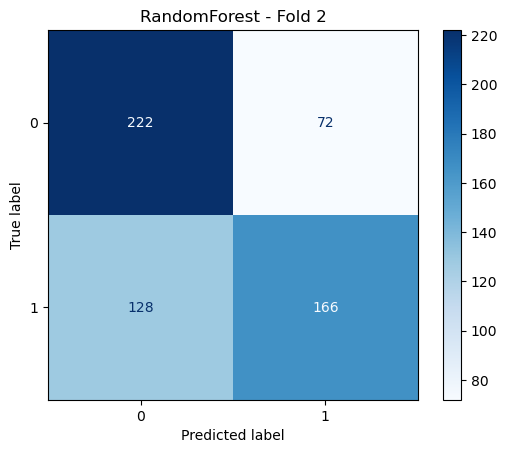

Fold 3: Acc=0.5020, Prec=0.4000, Rec=0.4898, F1=0.4404
Confusion Matrix:
 [[150 144]
 [100  96]] 



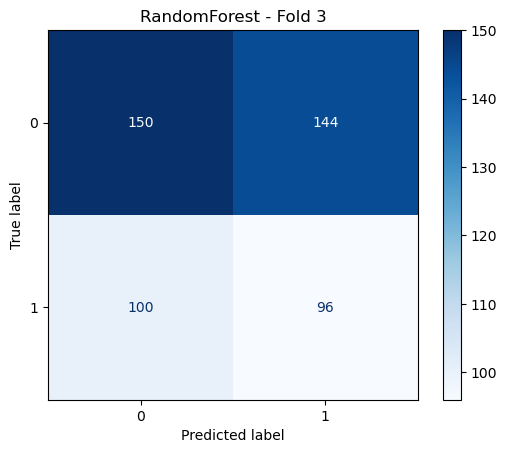

Fold 4: Acc=0.6367, Prec=0.5417, Rec=0.5969, F1=0.5680
Confusion Matrix:
 [[195  99]
 [ 79 117]] 



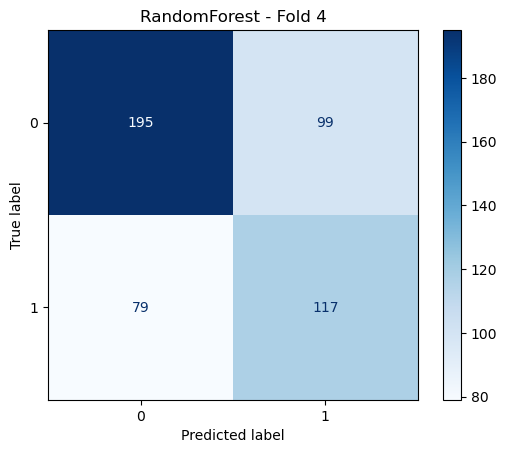

Fold 5: Acc=0.5408, Prec=0.6177, Rec=0.6156, F1=0.6167
Confusion Matrix:
 [[ 84 112]
 [113 181]] 



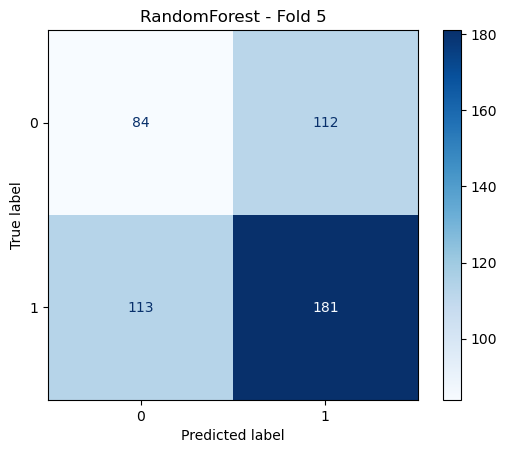


Average RandomForest: Acc=0.5532 | Prec=0.5578 | Rec=0.5262 | F1=0.5363


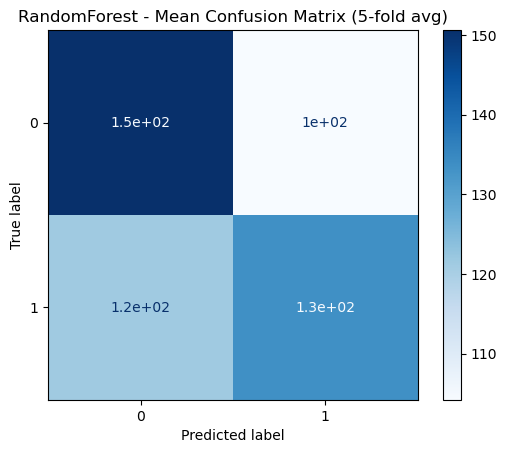


----- LogisticRegression -----
Fold 1: Acc=0.4898, Prec=0.5827, Rec=0.5272, F1=0.5536
Confusion Matrix:
 [[ 85 111]
 [139 155]] 



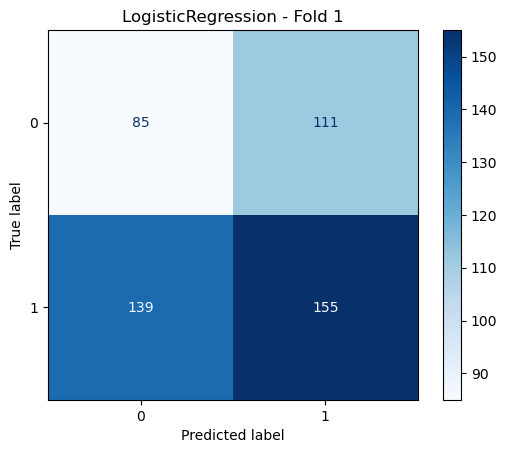

Fold 2: Acc=0.5765, Prec=0.5656, Rec=0.6599, F1=0.6091
Confusion Matrix:
 [[145 149]
 [100 194]] 



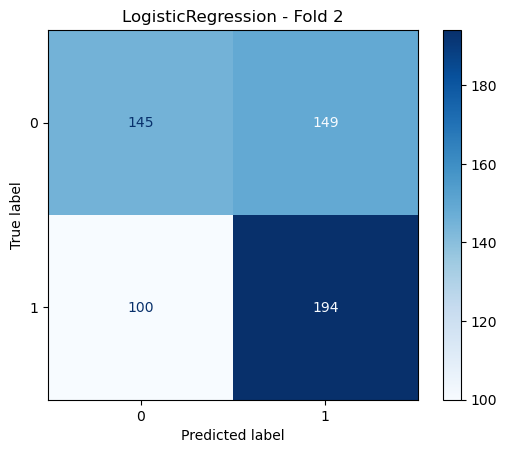

Fold 3: Acc=0.5959, Prec=0.4955, Rec=0.5561, F1=0.5240
Confusion Matrix:
 [[183 111]
 [ 87 109]] 



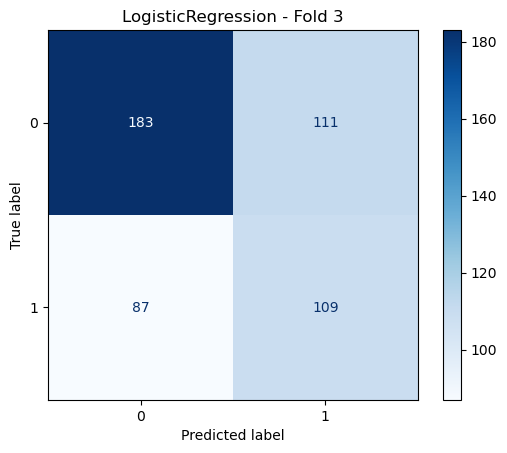

Fold 4: Acc=0.4796, Prec=0.3927, Rec=0.5510, F1=0.4586
Confusion Matrix:
 [[127 167]
 [ 88 108]] 



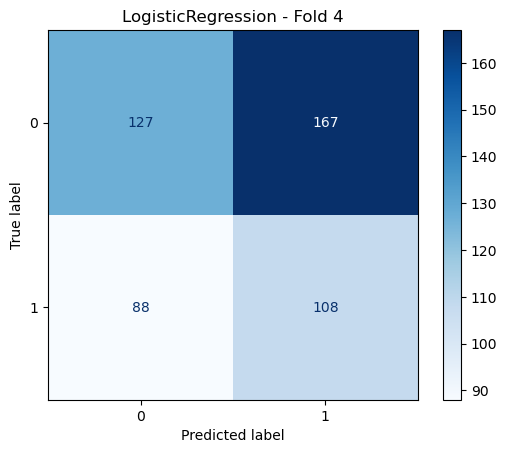

Fold 5: Acc=0.5204, Prec=0.5787, Rec=0.7381, F1=0.6487
Confusion Matrix:
 [[ 38 158]
 [ 77 217]] 



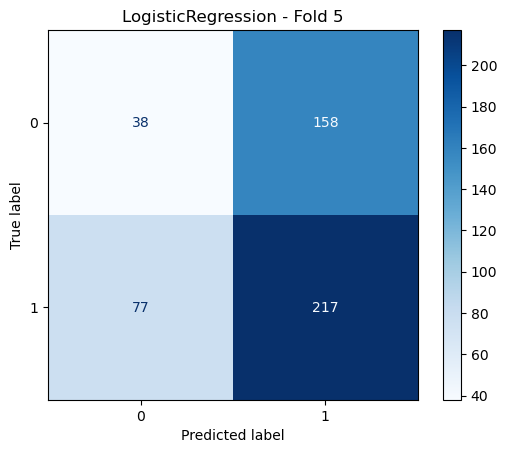


Average LogisticRegression: Acc=0.5324 | Prec=0.5230 | Rec=0.6065 | F1=0.5588


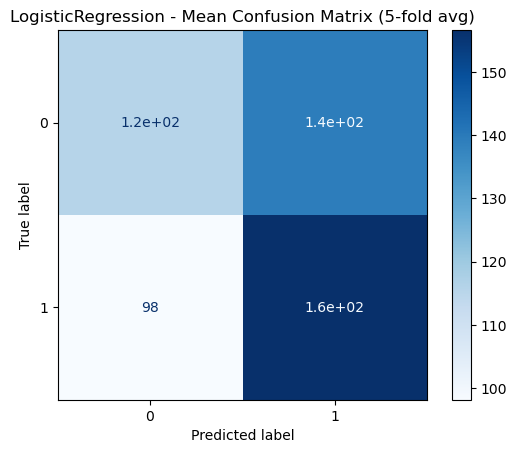


----- DecisionTree -----
Fold 1: Acc=0.4449, Prec=0.5466, Rec=0.4388, F1=0.4868
Confusion Matrix:
 [[ 89 107]
 [165 129]] 



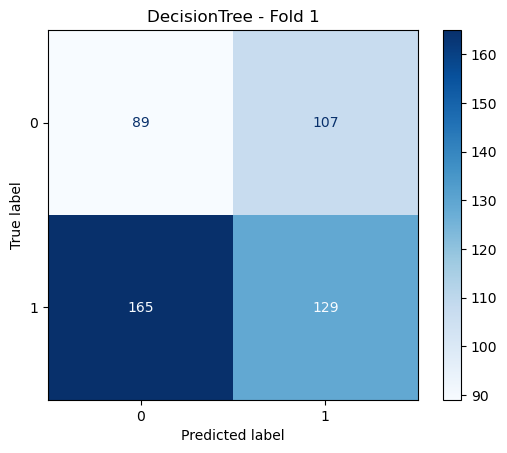

Fold 2: Acc=0.5969, Prec=0.5888, Rec=0.6429, F1=0.6146
Confusion Matrix:
 [[162 132]
 [105 189]] 



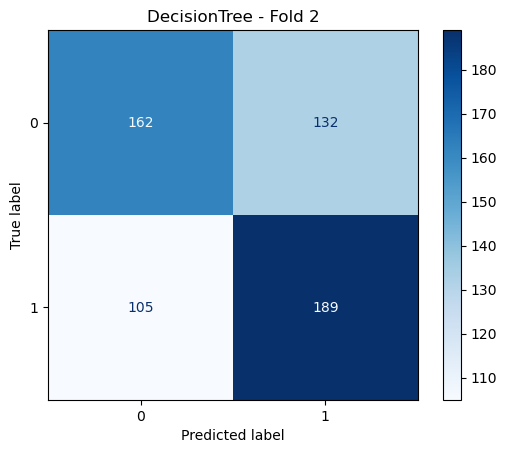

Fold 3: Acc=0.5082, Prec=0.4082, Rec=0.5102, F1=0.4535
Confusion Matrix:
 [[149 145]
 [ 96 100]] 



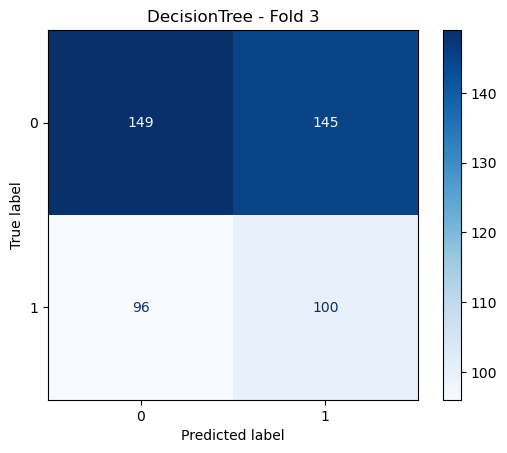

Fold 4: Acc=0.5612, Prec=0.4647, Rec=0.6378, F1=0.5376
Confusion Matrix:
 [[150 144]
 [ 71 125]] 



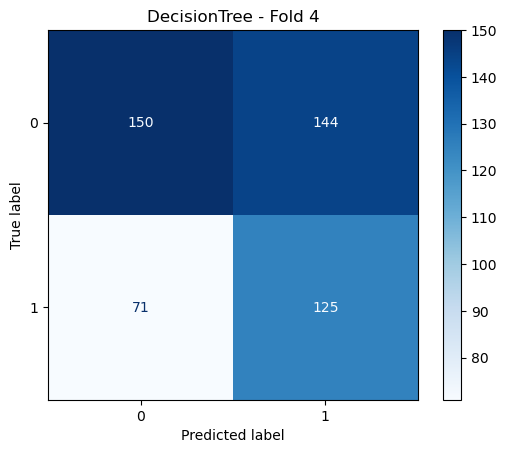

Fold 5: Acc=0.5347, Prec=0.6162, Rec=0.5952, F1=0.6055
Confusion Matrix:
 [[ 87 109]
 [119 175]] 



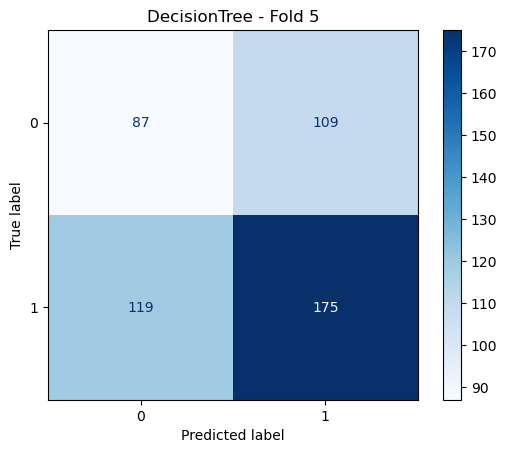


Average DecisionTree: Acc=0.5292 | Prec=0.5249 | Rec=0.5650 | F1=0.5396


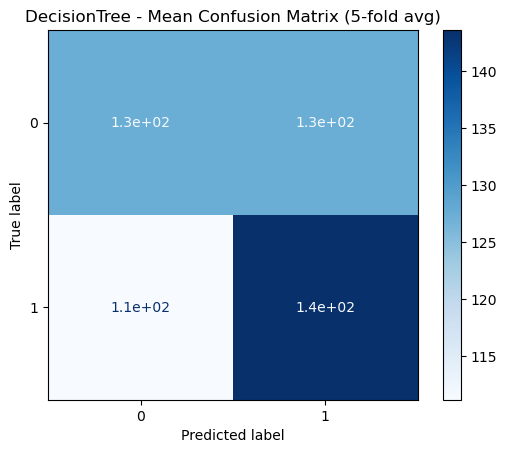


----- XGBoost -----
Fold 1: Acc=0.4469, Prec=0.5507, Rec=0.4252, F1=0.4798
Confusion Matrix:
 [[ 94 102]
 [169 125]] 



c:\Users\naili\anaconda3\envs\torch-gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:48] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


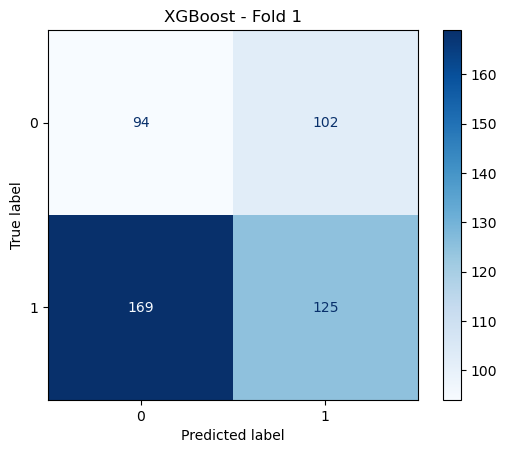

Fold 2: Acc=0.6327, Prec=0.6434, Rec=0.5952, F1=0.6184
Confusion Matrix:
 [[197  97]
 [119 175]] 



c:\Users\naili\anaconda3\envs\torch-gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:48] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


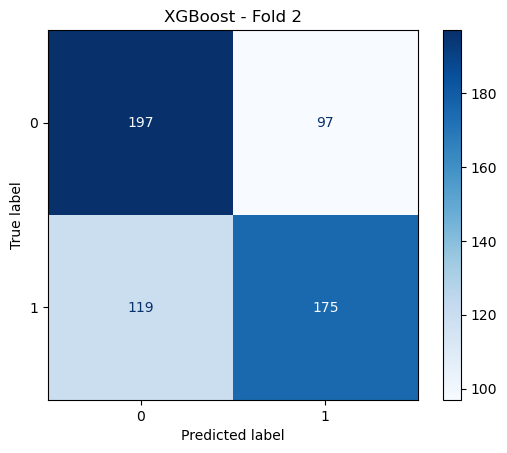

Fold 3: Acc=0.4816, Prec=0.3821, Rec=0.4796, F1=0.4253
Confusion Matrix:
 [[142 152]
 [102  94]] 



c:\Users\naili\anaconda3\envs\torch-gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:48] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


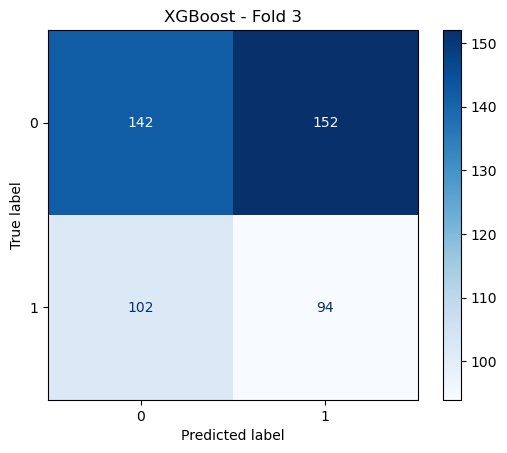

Fold 4: Acc=0.5939, Prec=0.4938, Rec=0.6122, F1=0.5467
Confusion Matrix:
 [[171 123]
 [ 76 120]] 



c:\Users\naili\anaconda3\envs\torch-gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:49] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


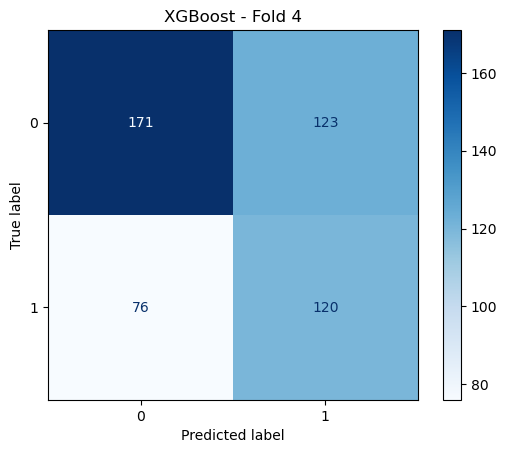

c:\Users\naili\anaconda3\envs\torch-gpu\lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:49] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5: Acc=0.5245, Prec=0.6007, Rec=0.6190, F1=0.6097
Confusion Matrix:
 [[ 75 121]
 [112 182]] 



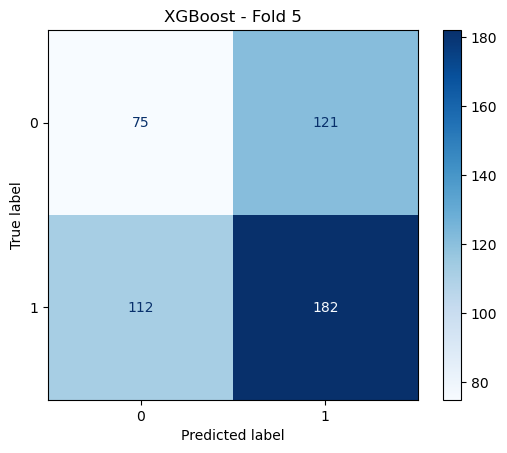


Average XGBoost: Acc=0.5359 | Prec=0.5341 | Rec=0.5463 | F1=0.5360


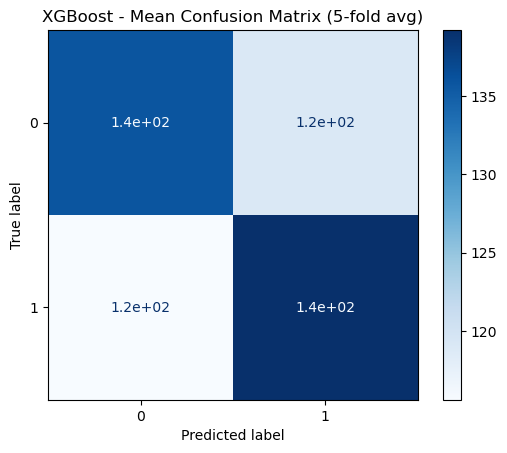


========== Summary of Traditional ML Models ==========
SVM                   Acc=0.5618 | Prec=0.5537 | Rec=0.6439 | F1=0.5901
RandomForest          Acc=0.5532 | Prec=0.5578 | Rec=0.5262 | F1=0.5363
LogisticRegression    Acc=0.5324 | Prec=0.5230 | Rec=0.6065 | F1=0.5588
DecisionTree          Acc=0.5292 | Prec=0.5249 | Rec=0.5650 | F1=0.5396
XGBoost               Acc=0.5359 | Prec=0.5341 | Rec=0.5463 | F1=0.5360


In [ ]:
# =============================================
# Traditional Machine Learning Comparison (with Confusion Matrices)
# =============================================


# Feature matrix and labels
X = erp_data  
y = labels
g = groups

classifiers = {
        "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42),
        "LogisticRegression": LogisticRegression(max_iter=10000, class_weight="balanced", solver="lbfgs", random_state=42),
        "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

gkf = StratifiedGroupKFold(n_splits=5)

print("\n========== Traditional ML Cross-Validation ==========")
results = []

for name, model in classifiers.items():
    print(f"\n----- {name} -----")
    fold_metrics = []
    cm_total = np.zeros((2, 2))  
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, g), 1):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Scale features
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        # Train & predict
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        # Metrics
        acc = accuracy_score(y_te, preds)
        prec = precision_score(y_te, preds, zero_division=0)
        rec = recall_score(y_te, preds, zero_division=0)
        f1 = f1_score(y_te, preds, zero_division=0)
        fold_metrics.append([acc, prec, rec, f1])

        # Confusion matrix
        cm = confusion_matrix(y_te, preds)
        cm_total += cm
        print(f"Fold {fold}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
        print("Confusion Matrix:\n", cm, "\n")

        # Optional: plot each fold confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Fold {fold}")
        plt.show()

    # Average metrics
    fold_metrics = np.array(fold_metrics)
    mean_acc, mean_prec, mean_rec, mean_f1 = fold_metrics.mean(axis=0)
    print(f"\nAverage {name}: "
          f"Acc={mean_acc:.4f} | Prec={mean_prec:.4f} | Rec={mean_rec:.4f} | F1={mean_f1:.4f}")

    # Plot mean confusion matrix
    cm_mean = cm_total / gkf.get_n_splits()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_mean)
    disp.plot(cmap='Blues')
    plt.title(f"{name} - Mean Confusion Matrix (5-fold avg)")
    plt.show()

    results.append([name, mean_acc, mean_prec, mean_rec, mean_f1])

# Summary table
print("\n========== Summary of Traditional ML Models ==========")
for name, acc, prec, rec, f1 in results:
    print(f"{name:20s}  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")
